# Stock Market Prediction & Buy Recommendation using LSTM

**What this notebook does:**
- Downloads real stock data from Kaggle (S&P 500 companies)
- Engineers financial features (RSI, MACD, Bollinger Bands, momentum, volume signals)
- Trains a deep LSTM model per stock to predict future closing price
- Evaluates accuracy (RMSE, MAPE, Directional Accuracy)
- Generates a Buy / Hold / Sell recommendation with expected profit % for each stock

**Run:** Runtime → Run all (Ctrl+F9)

>

## Section 0 — Install & Import Libraries

In [ ]:
# Install kagglehub silently
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])

0

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings, math, os
warnings.filterwarnings("ignore")

# ── Data ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import (
    Input, LSTM, Dense, Dropout,
    Bidirectional, BatchNormalization, Add, Activation
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam

# ── Kaggle ────────────────────────────────────────────────────────────────────
import kagglehub

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print("All libraries loaded successfully")

TensorFlow : 2.20.0
All libraries loaded successfully


## Section 1 — Configuration
**Edit only this cell to change behaviour.**

In [ ]:
# ── STOCKS TO ANALYSE ─────────────────────────────────────────────────────────
# Choose any tickers present in the Kaggle dataset
STOCKS_TO_ANALYSE = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",
                      "META", "TSLA", "JPM", "V", "JNJ"]

# ── MODEL SETTINGS ────────────────────────────────────────────────────────────
LOOKBACK      = 60    # number of past trading days the LSTM sees
FORECAST_DAYS = 30    # how many days ahead to predict for recommendation
EPOCHS        = 2    # max training epochs (EarlyStopping will stop sooner)
BATCH_SIZE    = 32
TRAIN_RATIO   = 0.80  # 80% train, 20% test

# ── RECOMMENDATION THRESHOLDS ─────────────────────────────────────────────────
BUY_THRESHOLD  =  3.0   # predicted gain % above this -> BUY
SELL_THRESHOLD = -2.0   # predicted gain % below this -> SELL
# Between SELL_THRESHOLD and BUY_THRESHOLD -> HOLD

print("Configuration loaded")
print(f"  Stocks     : {STOCKS_TO_ANALYSE}")
print(f"  Lookback   : {LOOKBACK} days")
print(f"  Forecast   : {FORECAST_DAYS} days ahead")
print(f"  Epochs     : {EPOCHS}")
print(f"  Buy if     : predicted gain > {BUY_THRESHOLD}%")
print(f"  Sell if    : predicted gain < {SELL_THRESHOLD}%")

Configuration loaded
  Stocks     : ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'V', 'JNJ']
  Lookback   : 60 days
  Forecast   : 30 days ahead
  Epochs     : 2
  Buy if     : predicted gain > 3.0%
  Sell if    : predicted gain < -2.0%


## Section 2 — Download & Load Stock Data from Kaggle

In [ ]:
# Download S&P 500 historical stock data from Kaggle
# Dataset: "camnugent/sandp500" — contains individual CSV per stock
print("Downloading S&P 500 dataset from Kaggle...")
path = kagglehub.dataset_download("camnugent/sandp500")
print(f"Downloaded to: {path}")

# List available files
files = os.listdir(path)
print(f"\nTotal files in dataset: {len(files)}")
print(f"Sample files: {files[:10]}")

Using Colab cache for faster access to the 'sandp500' dataset.
Downloaded to: /kaggle/input/sandp500

Total files in dataset: 4
Sample files: ['merge.sh', 'getSandP.py', 'individual_stocks_5yr', 'all_stocks_5yr.csv']


In [ ]:
import os

# See exactly what files are in the dataset
all_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        all_files.append(os.path.join(root, f))

print(f"Total files found: {len(all_files)}")
print("\nFirst 20 files:")
for f in all_files[:20]:
    print(" ", f)

Total files found: 514

First 20 files:
  /kaggle/input/sandp500/merge.sh
  /kaggle/input/sandp500/getSandP.py
  /kaggle/input/sandp500/all_stocks_5yr.csv
  /kaggle/input/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._.DS_Store
  /kaggle/input/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._ABC_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._AAPL_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._A_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._MAS_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individual_stocks_5yr/CL_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individual_stocks_5yr/FDX_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individual_stocks_5yr/AMAT_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individual_stocks_5yr/GLW_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individua

In [ ]:
import kagglehub, os, math
import pandas as pd
import numpy as np

print("Downloading S&P 500 dataset from Kaggle...")
path = kagglehub.dataset_download("camnugent/sandp500")
print(f"Downloaded to: {path}")

# ── Find the combined CSV ─────────────────────────────────────────────────────
csv_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print(f"\nCSV files found:")
for f in csv_files:
    print(f"  {f}")

# The dataset has one large file: all_stocks_5yr.csv
# Pick the biggest CSV (that is the combined one)
main_csv = max(csv_files, key=lambda f: os.path.getsize(f))
print(f"\nLoading: {main_csv}")

all_stocks_df = pd.read_csv(main_csv)
print(f"Shape         : {all_stocks_df.shape}")
print(f"Columns       : {all_stocks_df.columns.tolist()}")
print(f"Tickers found : {all_stocks_df['Name'].nunique()}")
print(f"Sample tickers: {sorted(all_stocks_df['Name'].unique())[:15]}")

Using Colab cache for faster access to the 'sandp500' dataset.
Downloaded to: /kaggle/input/sandp500

CSV files found:
  /kaggle/input/sandp500/all_stocks_5yr.csv
  /kaggle/input/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._ABC_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._AAPL_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._A_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._MAS_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individual_stocks_5yr/CL_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individual_stocks_5yr/FDX_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individual_stocks_5yr/AMAT_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individual_stocks_5yr/GLW_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individual_stocks_5yr/ANSS_data.csv
  /kaggle/input/sandp500/individual_stocks_5yr/individu

In [ ]:
def load_stock(ticker: str, combined_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts a single ticker from the combined all_stocks_5yr.csv dataframe.
    Standardises column names, parses dates, sorts, and drops NaNs.
    """
    df = combined_df[combined_df["Name"] == ticker].copy()

    if df.empty:
        return None

    # Standardise column names to lowercase
    df.columns = [c.strip().lower() for c in df.columns]

    # Rename to standard OHLCV names
    col_map = {
        "date"   : "date",
        "open"   : "open",
        "high"   : "high",
        "low"    : "low",
        "close"  : "close",
        "volume" : "volume",
    }
    df.rename(columns=col_map, inplace=True)

    required = ["date", "open", "high", "low", "close", "volume"]
    if any(c not in df.columns for c in required):
        return None

    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)
    df.sort_index(inplace=True)

    df = df[["open", "high", "low", "close", "volume"]].copy()
    df = df.apply(pd.to_numeric, errors="coerce")
    df.dropna(inplace=True)

    return df


# ── Load all requested stocks ─────────────────────────────────────────────────
stock_data = {}
failed     = []

for ticker in STOCKS_TO_ANALYSE:
    df = load_stock(ticker, all_stocks_df)
    if df is not None and len(df) > LOOKBACK + FORECAST_DAYS + 50:
        stock_data[ticker] = df
        print(f"  {ticker:6s}  {len(df):5,} rows  "
              f"{df.index[0].date()} -> {df.index[-1].date()}")
    else:
        failed.append(ticker)
        print(f"  {ticker:6s}  NOT FOUND or insufficient data")

print(f"\nLoaded   : {len(stock_data)} stocks")
if failed:
    print(f"Failed   : {failed}")
    # Show which tickers ARE available so you can update STOCKS_TO_ANALYSE
    available = sorted(all_stocks_df["Name"].unique())
    print(f"\nAvailable tickers (first 30): {available[:30]}")

  AAPL    1,259 rows  2013-02-08 -> 2018-02-07
  MSFT    1,259 rows  2013-02-08 -> 2018-02-07
  GOOGL   1,259 rows  2013-02-08 -> 2018-02-07
  AMZN    1,259 rows  2013-02-08 -> 2018-02-07
  NVDA    1,259 rows  2013-02-08 -> 2018-02-07
  META    NOT FOUND or insufficient data
  TSLA    NOT FOUND or insufficient data
  JPM     1,259 rows  2013-02-08 -> 2018-02-07
  V       1,259 rows  2013-02-08 -> 2018-02-07
  JNJ     1,259 rows  2013-02-08 -> 2018-02-07

Loaded   : 8 stocks
Failed   : ['META', 'TSLA']

Available tickers (first 30): ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AGN', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'ALL', 'ALLE']


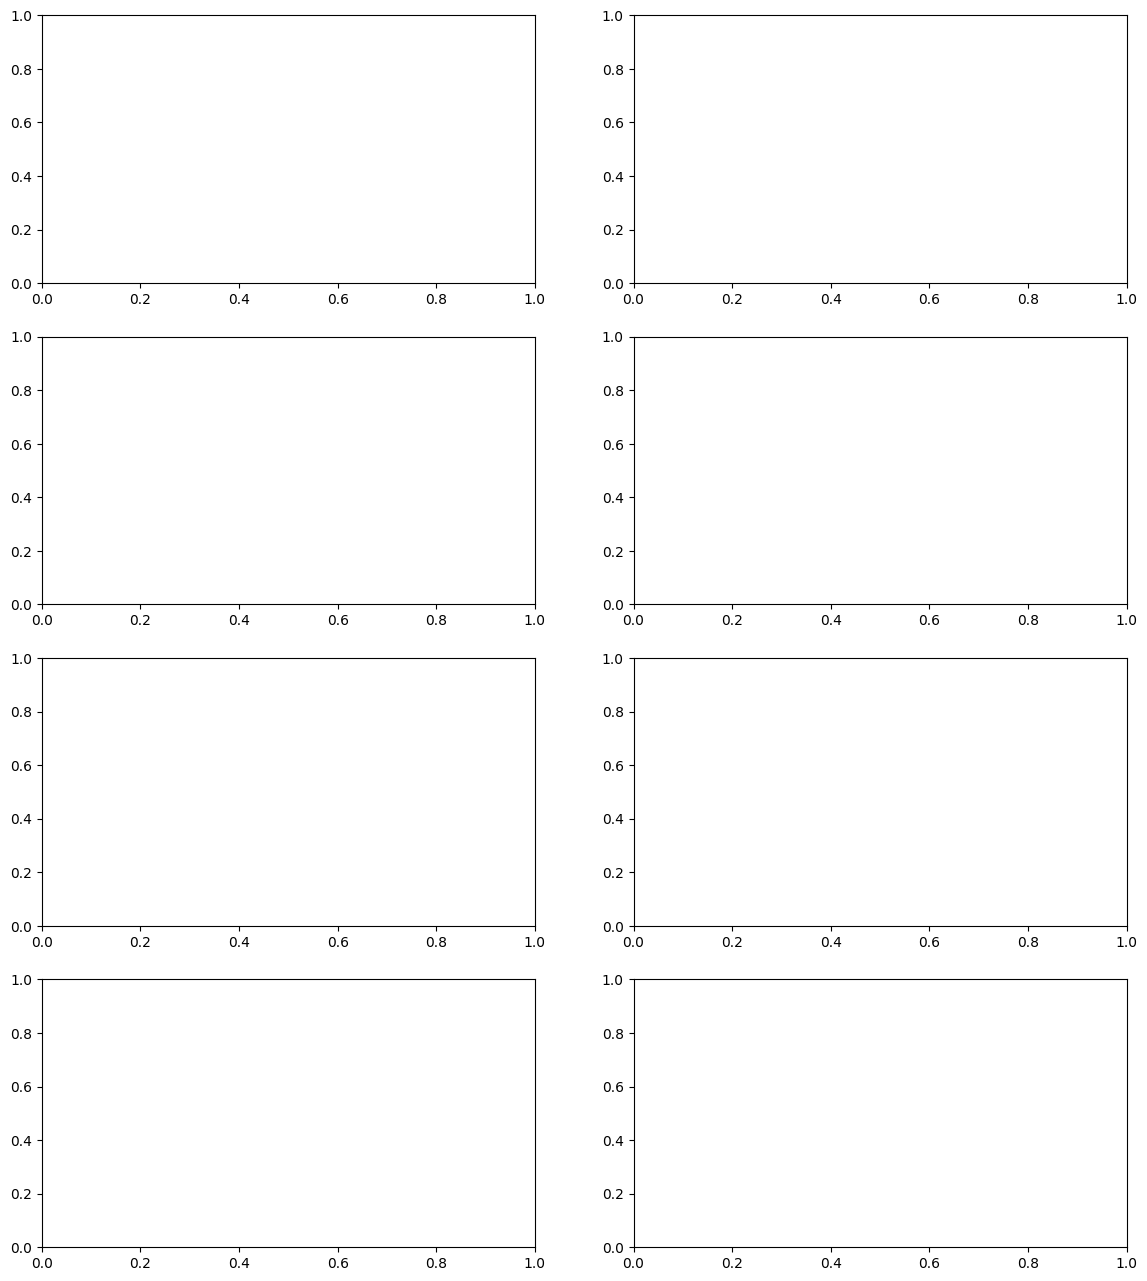

In [ ]:
# Guard — skip plotting if no stocks loaded
if len(stock_data) == 0:
    print("No stocks loaded. Check ticker names above and rerun Section 2.")
else:
    n    = len(stock_data)
    cols = min(2, n)               # never more columns than stocks
    rows = math.ceil(n / cols)     # always at least 1

    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = np.array(axes).flatten()   # works for 1 stock or many
    # ... rest of plotting code

## Section 3 — Exploratory Data Analysis

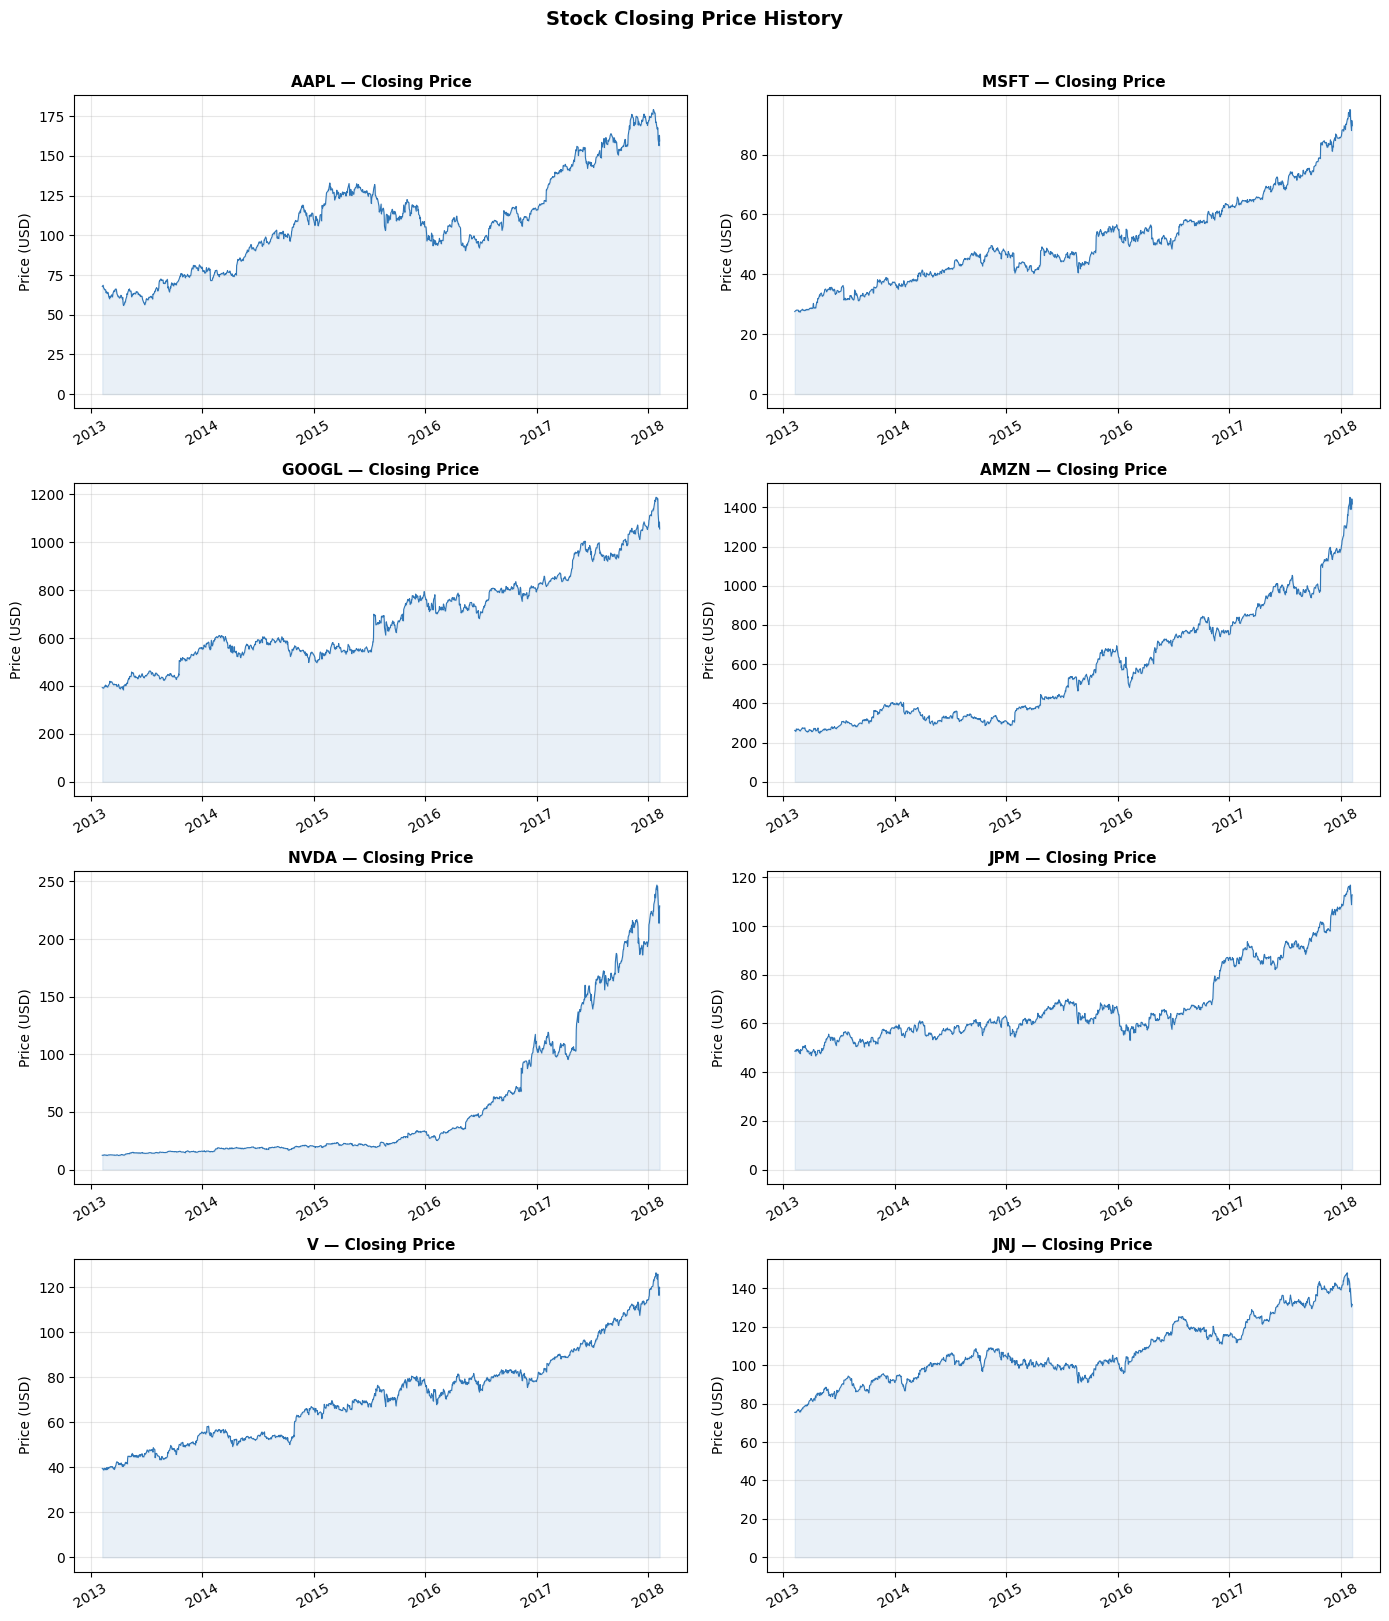

In [ ]:
# Plot closing price history for all loaded stocks
n = len(stock_data)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (ticker, df) in zip(axes, stock_data.items()):
    ax.plot(df.index, df["close"], linewidth=0.8, color="#2E75B6")
    ax.fill_between(df.index, df["close"], alpha=0.1, color="#2E75B6")
    ax.set_title(f"{ticker} — Closing Price", fontsize=11, fontweight="bold")
    ax.set_ylabel("Price (USD)")
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

# Hide any unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Stock Closing Price History", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

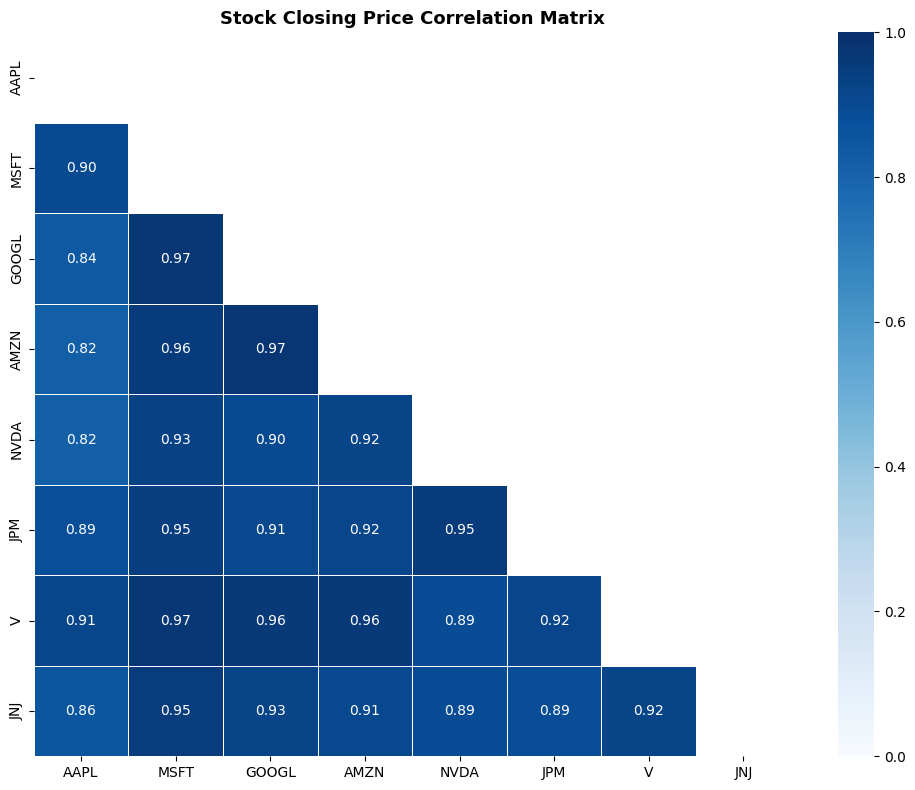

In [ ]:
# Correlation heatmap of closing prices (normalised to start = 1)
close_df = pd.DataFrame({
    ticker: df["close"] / df["close"].iloc[0]
    for ticker, df in stock_data.items()
})

# Use the common date range
close_df.dropna(inplace=True)

plt.figure(figsize=(10, 8))
corr = close_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="Blues", linewidths=0.5, vmin=0, vmax=1)
plt.title("Stock Closing Price Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 4 — Financial Feature Engineering

| Feature | Description |
|---|---|
| Returns | Daily percentage change in close price |
| Log Returns | More stable for modelling than raw returns |
| SMA 10/20/50 | Simple moving averages |
| EMA 12/26 | Exponential moving averages |
| MACD | EMA12 - EMA26 (momentum signal) |
| RSI | Relative Strength Index (overbought/oversold) |
| Bollinger Bands | Upper/lower band + bandwidth |
| ATR | Average True Range (volatility) |
| OBV | On-Balance Volume (volume momentum) |
| Price vs SMA ratio | How far price is from its average |
| High-Low spread | Daily price range |
| Volume change | Daily volume momentum |

In [ ]:
def engineer_stock_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds standard financial technical indicators to the OHLCV dataframe.
    All features are derived solely from OHLCV — no external data needed.
    Input  : DataFrame with open, high, low, close, volume columns
    Output : DataFrame with 20+ additional technical indicator columns
    """
    feat = df.copy()
    C = feat["close"]
    H = feat["high"]
    L = feat["low"]
    V = feat["volume"]

    # ── Price-based features ──────────────────────────────────────────────────

    # Daily returns and log returns
    feat["returns"]     = C.pct_change()                          # % change
    feat["log_returns"] = np.log(C / C.shift(1))                  # log return

    # Simple Moving Averages — trend direction
    feat["sma_10"]  = C.rolling(window=10).mean()
    feat["sma_20"]  = C.rolling(window=20).mean()
    feat["sma_50"]  = C.rolling(window=50).mean()

    # Exponential Moving Averages — more weight on recent prices
    feat["ema_12"]  = C.ewm(span=12, adjust=False).mean()
    feat["ema_26"]  = C.ewm(span=26, adjust=False).mean()

    # MACD — momentum: when EMA12 crosses above EMA26 it is bullish
    feat["macd"]         = feat["ema_12"] - feat["ema_26"]
    feat["macd_signal"]  = feat["macd"].ewm(span=9, adjust=False).mean()
    feat["macd_hist"]    = feat["macd"] - feat["macd_signal"]

    # RSI — Relative Strength Index (14-day)
    # RSI > 70 = overbought (potential sell), RSI < 30 = oversold (potential buy)
    delta     = C.diff()
    gain      = delta.clip(lower=0)
    loss      = (-delta).clip(lower=0)
    avg_gain  = gain.rolling(window=14).mean()
    avg_loss  = loss.rolling(window=14).mean()
    rs        = avg_gain / (avg_loss + 1e-8)
    feat["rsi"] = 100 - (100 / (1 + rs))

    # Bollinger Bands (20-day, 2 std dev)
    bb_mean              = C.rolling(20).mean()
    bb_std               = C.rolling(20).std()
    feat["bb_upper"]     = bb_mean + 2 * bb_std
    feat["bb_lower"]     = bb_mean - 2 * bb_std
    feat["bb_bandwidth"] = (feat["bb_upper"] - feat["bb_lower"]) / bb_mean
    feat["bb_position"]  = (C - feat["bb_lower"]) / (feat["bb_upper"] - feat["bb_lower"] + 1e-8)

    # ATR — Average True Range (volatility measure)
    tr1 = H - L
    tr2 = (H - C.shift(1)).abs()
    tr3 = (L - C.shift(1)).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    feat["atr"] = true_range.rolling(14).mean()

    # High-Low spread (daily range as % of close)
    feat["hl_spread"] = (H - L) / C

    # Price distance from SMA (how stretched the price is)
    feat["price_vs_sma20"] = (C - feat["sma_20"]) / feat["sma_20"]
    feat["price_vs_sma50"] = (C - feat["sma_50"]) / feat["sma_50"]

    # ── Volume-based features ─────────────────────────────────────────────────

    # OBV — On-Balance Volume: cumulative volume based on price direction
    obv = [0]
    for i in range(1, len(C)):
        if C.iloc[i] > C.iloc[i-1]:
            obv.append(obv[-1] + V.iloc[i])
        elif C.iloc[i] < C.iloc[i-1]:
            obv.append(obv[-1] - V.iloc[i])
        else:
            obv.append(obv[-1])
    feat["obv"] = obv

    # Volume moving average and ratio
    feat["vol_sma20"]  = V.rolling(20).mean()
    feat["vol_ratio"]  = V / feat["vol_sma20"]   # >1 means above-average volume
    feat["vol_change"] = V.pct_change()

    # ── Lag features for close price ─────────────────────────────────────────

    for lag in [1, 2, 3, 5, 10]:
        feat[f"close_lag{lag}"] = C.shift(lag)

    # Drop NaN rows introduced by rolling windows and lags
    feat.dropna(inplace=True)

    return feat


# Apply feature engineering to all stocks
stock_feat = {}
for ticker, df in stock_data.items():
    stock_feat[ticker] = engineer_stock_features(df)
    print(f"  {ticker:6s}  {stock_feat[ticker].shape[1]} features  {len(stock_feat[ticker]):,} rows")

print(f"\nFeatures per stock: {stock_feat[list(stock_feat.keys())[0]].columns.tolist()}")

  AAPL    33 features  1,210 rows
  MSFT    33 features  1,210 rows
  GOOGL   33 features  1,210 rows
  AMZN    33 features  1,210 rows
  NVDA    33 features  1,210 rows
  JPM     33 features  1,210 rows
  V       33 features  1,210 rows
  JNJ     33 features  1,210 rows

Features per stock: ['open', 'high', 'low', 'close', 'volume', 'returns', 'log_returns', 'sma_10', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'macd_hist', 'rsi', 'bb_upper', 'bb_lower', 'bb_bandwidth', 'bb_position', 'atr', 'hl_spread', 'price_vs_sma20', 'price_vs_sma50', 'obv', 'vol_sma20', 'vol_ratio', 'vol_change', 'close_lag1', 'close_lag2', 'close_lag3', 'close_lag5', 'close_lag10']


## Section 5 — Data Preparation for LSTM

In [ ]:
def prepare_lstm_data(df: pd.DataFrame, lookback: int, train_ratio: float):
    """
    Scales all features, creates sliding-window sequences, and splits
    chronologically into train and test sets.

    Returns:
      X_train, y_train  — training sequences and targets
      X_test,  y_test   — test sequences and targets
      scaler_close      — scaler fitted only on close price (for inverse transform)
      scaler_all        — scaler fitted on all features
      feature_names     — list of column names
    """
    feature_names = df.columns.tolist()
    close_idx     = feature_names.index("close")

    # Fit scaler on training portion only — prevents data leakage
    n_train = int(len(df) * train_ratio)

    scaler_all   = MinMaxScaler(feature_range=(0, 1))
    scaler_close = MinMaxScaler(feature_range=(0, 1))

    train_arr = df.values[:n_train]
    test_arr  = df.values[n_train:]

    scaler_all.fit(train_arr)
    scaler_close.fit(train_arr[:, close_idx].reshape(-1, 1))

    train_scaled = scaler_all.transform(train_arr)
    test_scaled  = scaler_all.transform(test_arr)

    def make_sequences(data, lookback):
        X, y = [], []
        for i in range(lookback, len(data)):
            X.append(data[i - lookback : i, :])        # all features, past N days
            y.append(data[i, close_idx])               # tomorrow's close (scaled)
        return np.array(X), np.array(y)

    X_train, y_train = make_sequences(train_scaled, lookback)
    X_test,  y_test  = make_sequences(test_scaled,  lookback)

    return X_train, y_train, X_test, y_test, scaler_close, scaler_all, feature_names, close_idx


# Prepare data for all stocks
prepared = {}
for ticker, df in stock_feat.items():
    result = prepare_lstm_data(df, LOOKBACK, TRAIN_RATIO)
    prepared[ticker] = result
    X_train, y_train, X_test, y_test = result[:4]
    print(f"  {ticker:6s}  X_train={X_train.shape}  X_test={X_test.shape}")

  AAPL    X_train=(908, 60, 33)  X_test=(182, 60, 33)
  MSFT    X_train=(908, 60, 33)  X_test=(182, 60, 33)
  GOOGL   X_train=(908, 60, 33)  X_test=(182, 60, 33)
  AMZN    X_train=(908, 60, 33)  X_test=(182, 60, 33)
  NVDA    X_train=(908, 60, 33)  X_test=(182, 60, 33)
  JPM     X_train=(908, 60, 33)  X_test=(182, 60, 33)
  V       X_train=(908, 60, 33)  X_test=(182, 60, 33)
  JNJ     X_train=(908, 60, 33)  X_test=(182, 60, 33)


## Section 6 — LSTM Model Architecture

```
Input (lookback=60 days, n_features=~32)
    ↓
Bidirectional LSTM (128 units)  — reads sequence forward and backward
    ↓
Dropout (0.3)
    ↓
Bidirectional LSTM (64 units)   — deeper temporal abstraction
    ↓
Dropout (0.2)
    ↓
LSTM (32 units)                 — final sequence compression
    ↓
BatchNormalization
    ↓
Dense (64, relu) → Dense (32, relu) → Dense (1)
    ↓
Predicted next-day close price (scaled)
```

In [ ]:
def build_stock_lstm(input_shape: tuple) -> keras.Model:
    """
    Deep stacked Bidirectional LSTM for stock price prediction.
    Uses only LSTM layers — no CNN, no Transformer.

    input_shape : (lookback, n_features)
    output      : single float — predicted next-day close price (scaled)
    """
    inputs = Input(shape=input_shape, name="ohlcv_features")

    # Layer 1: Bidirectional LSTM — captures both uptrend and downtrend patterns
    x = Bidirectional(
        LSTM(128, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
        name="bilstm_1"
    )(inputs)
    x = Dropout(0.3, name="drop_1")(x)

    # Layer 2: Second Bidirectional LSTM — deeper pattern abstraction
    x = Bidirectional(
        LSTM(64, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
        name="bilstm_2"
    )(x)
    x = Dropout(0.2, name="drop_2")(x)

    # Layer 3: Unidirectional LSTM — final temporal compression to single vector
    x = LSTM(32, return_sequences=False, name="lstm_3")(x)
    x = BatchNormalization(name="batch_norm")(x)

    # Dense regression head
    x = Dense(64, activation="relu", name="dense_1")(x)
    x = Dropout(0.1, name="drop_3")(x)
    x = Dense(32, activation="relu", name="dense_2")(x)
    output = Dense(1, name="price_output")(x)   # single price prediction

    model = keras.Model(inputs, output, name="StockLSTM")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="huber",    # Huber loss is more robust to price spike outliers than MSE
        metrics=["mae"]
    )
    return model


# Show model architecture for first stock
ticker_0    = list(prepared.keys())[0]
X_train_0   = prepared[ticker_0][0]
sample_model = build_stock_lstm(input_shape=(X_train_0.shape[1], X_train_0.shape[2]))
sample_model.summary()

Model: "StockLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ohlcv_features (InputLayer)     │ (None, 60, 33)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 60, 256)        │       165,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 60, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_output (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,201 (1.35 MB)

 Trainable params: 355,137 (1.35 MB)

 Non-trainable params: 64 (256.00 B)

## Section 7 — Train LSTM for Each Stock

In [ ]:
trained_models  = {}   # stores the fitted Keras model
training_history = {}  # stores loss curves

for ticker in prepared.keys():
    X_train, y_train, X_test, y_test, scaler_close, scaler_all, feat_names, close_idx = prepared[ticker]

    print(f"\n{'='*55}")
    print(f"  Training LSTM for {ticker}")
    print(f"{'='*55}")

    # Build a fresh model for each stock
    model = build_stock_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        ),
        ModelCheckpoint(
            filepath=f"{ticker}_best.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=0
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    trained_models[ticker]   = model
    training_history[ticker] = history

print("\nAll stocks trained successfully")


  Training LSTM for AAPL
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 804ms/step - loss: 0.1141 - mae: 0.3522 - val_loss: 0.0472 - val_mae: 0.2948 - learning_rate: 0.0010
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 725ms/step - loss: 0.0225 - mae: 0.1622 - val_loss: 0.0479 - val_mae: 0.2961 - learning_rate: 0.0010

  Training LSTM for MSFT
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 802ms/step - loss: 0.2193 - mae: 0.4919 - val_loss: 0.1502 - val_mae: 0.5434 - learning_rate: 0.0010
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 745ms/step - loss: 0.0163 - mae: 0.1374 - val_loss: 0.1629 - val_mae: 0.5663 - learning_rate: 0.0010

  Training LSTM for GOOGL
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 794ms/step - loss: 0.0380 - mae: 0.2108 - val_loss: 0.1905 - val_mae: 0.6157 - learning_rate: 0.0010
Epoch 2/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 697ms/step - loss: 0.0140 - mae: 0.1310 - val_loss: 0.1900 - val_mae: 0.6149 - learning_rate: 0.0010

  Training LSTM for AMZN
Epoch 1/2
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 81

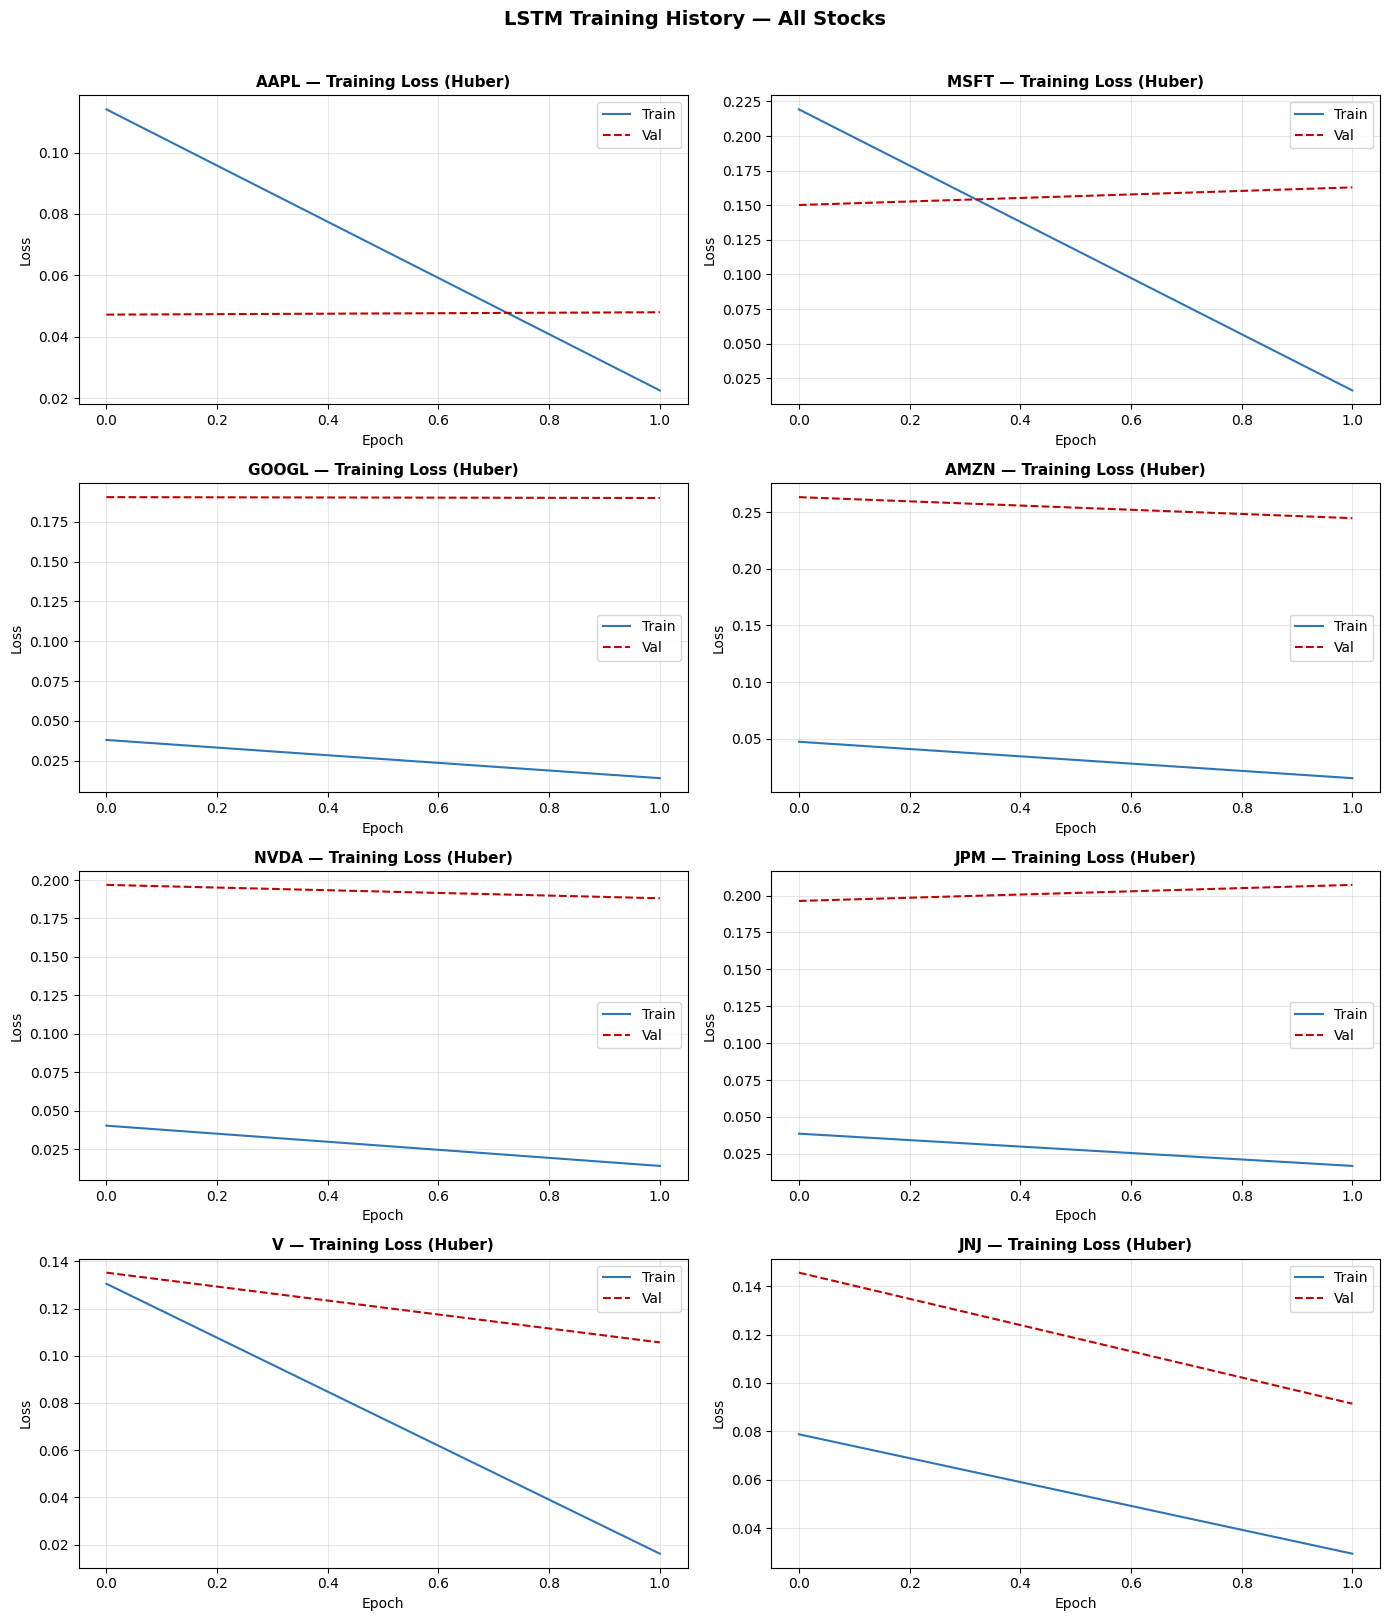

In [ ]:
# Training loss curves for all stocks
n    = len(trained_models)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (ticker, history) in zip(axes, training_history.items()):
    ax.plot(history.history["loss"],     label="Train", color="#2E75B6")
    ax.plot(history.history["val_loss"], label="Val",   color="#C00000", linestyle="--")
    ax.set_title(f"{ticker} — Training Loss (Huber)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("LSTM Training History — All Stocks", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Section 8 — Evaluate Model Accuracy

In [ ]:
def evaluate_stock_model(model, X_test, y_test, scaler_close, ticker):
    """
    Runs predictions on the test set, inverse-transforms back to USD,
    and computes RMSE, MAE, MAPE, R², and Directional Accuracy.

    Directional Accuracy = % of days where model correctly predicted
    whether price would go UP or DOWN (most important for trading).
    """
    # Raw predictions (scaled 0-1)
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()

    # Inverse transform to real USD prices
    y_pred = scaler_close.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler_close.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Standard regression metrics
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)

    # Directional accuracy — did we get UP/DOWN right?
    actual_dir    = np.sign(np.diff(y_true))
    predicted_dir = np.sign(np.diff(y_pred))
    dir_accuracy  = np.mean(actual_dir == predicted_dir) * 100

    return {
        "Ticker"         : ticker,
        "RMSE (USD)"     : round(rmse, 4),
        "MAE (USD)"      : round(mae,  4),
        "MAPE (%)"       : round(mape, 2),
        "R²"             : round(r2,   4),
        "Dir Accuracy (%)" : round(dir_accuracy, 1),
        "y_true"         : y_true,
        "y_pred"         : y_pred
    }


# Evaluate all stocks
eval_results = {}

print(f"{'Ticker':8s}  {'RMSE':>8s}  {'MAE':>8s}  {'MAPE%':>8s}  {'R²':>6s}  {'Dir Acc%':>10s}")
print("-" * 60)

for ticker in trained_models:
    model         = trained_models[ticker]
    X_train, y_train, X_test, y_test, scaler_close, *_ = prepared[ticker]
    result        = evaluate_stock_model(model, X_test, y_test, scaler_close, ticker)
    eval_results[ticker] = result
    print(f"{ticker:8s}  "
          f"{result['RMSE (USD)']:>8.2f}  "
          f"{result['MAE (USD)']:>8.2f}  "
          f"{result['MAPE (%)']:>7.1f}%  "
          f"{result['R²']:>6.3f}  "
          f"{result['Dir Accuracy (%)']:>9.1f}%")

Ticker        RMSE       MAE     MAPE%      R²    Dir Acc%
------------------------------------------------------------
AAPL         68.68     67.94     42.0%  -45.178       54.1%
MSFT         37.27     36.57     46.4%  -25.718       56.9%


GOOGL       482.80    478.26     47.2%  -50.660       47.0%


AMZN        710.08    698.21     64.6%  -28.475       49.2%
NVDA        160.73    158.42     86.2%  -33.098       51.9%
JPM          48.15     47.33     48.3%  -29.524       44.8%
V            46.38     45.58     42.5%  -27.512       53.0%
JNJ          36.68     36.37     26.6%  -54.057       58.0%


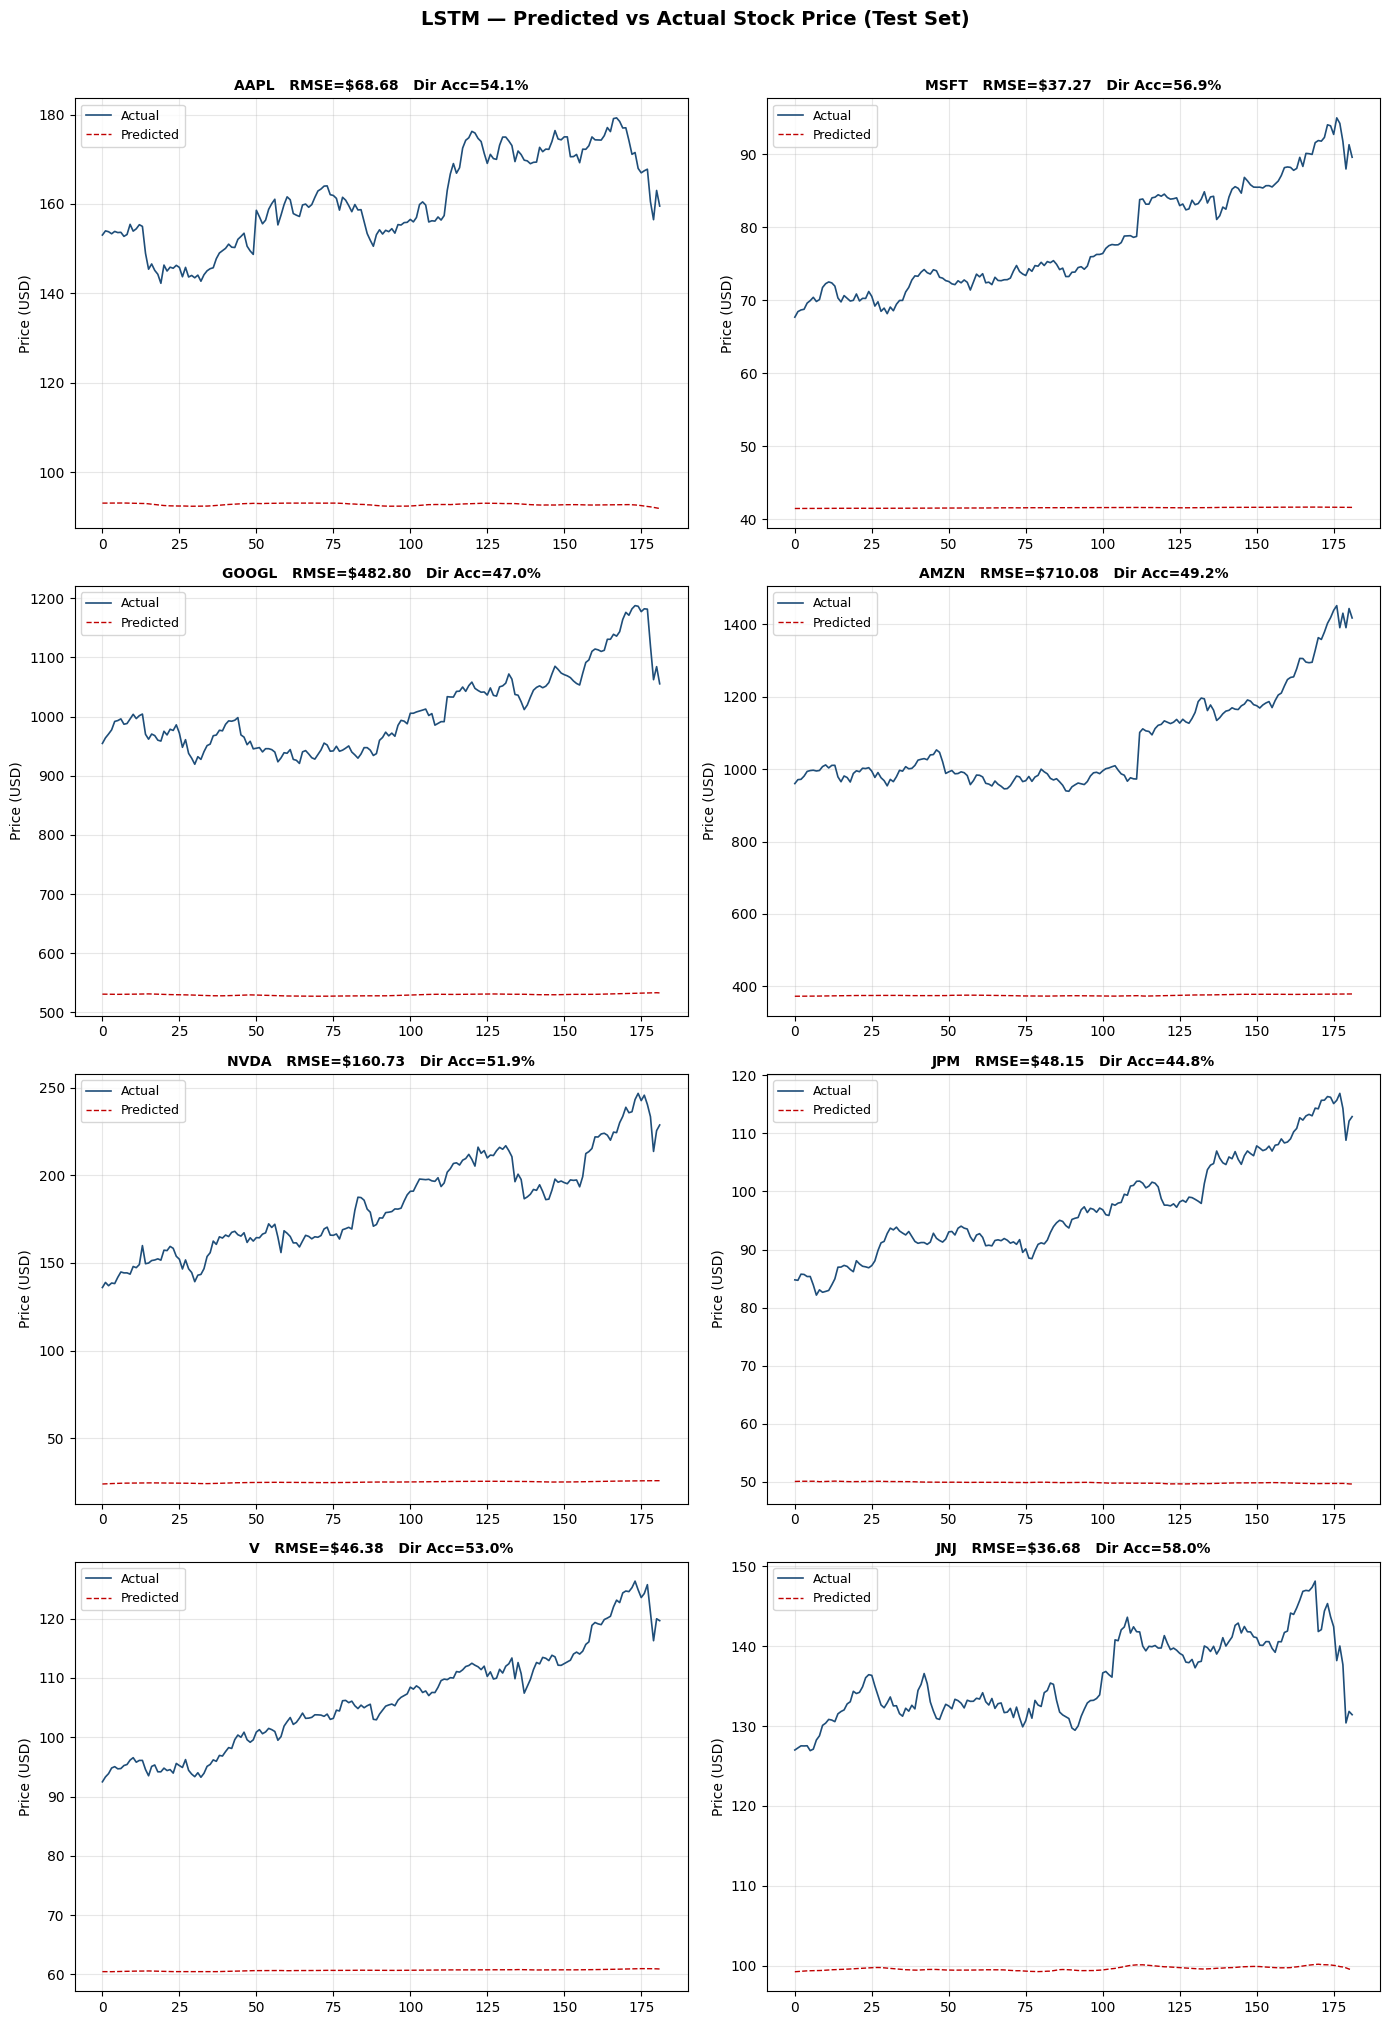

In [ ]:
# Plot predicted vs actual price for all stocks
n    = len(eval_results)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (ticker, result) in zip(axes, eval_results.items()):
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    plot_n = min(len(y_true), 252)   # plot last year of test data

    ax.plot(y_true[-plot_n:], label="Actual",    color="#1F4E79", linewidth=1.2)
    ax.plot(y_pred[-plot_n:], label="Predicted", color="#C00000", linewidth=1.0, linestyle="--")
    ax.set_title(
        f"{ticker}   RMSE=${result['RMSE (USD)']:.2f}   "
        f"Dir Acc={result['Dir Accuracy (%)']:.1f}%",
        fontsize=10, fontweight="bold"
    )
    ax.set_ylabel("Price (USD)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("LSTM — Predicted vs Actual Stock Price (Test Set)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Section 9 — Future Price Forecast & Buy/Sell Recommendation

In [ ]:
def forecast_future(model, df_feat: pd.DataFrame, scaler_all, scaler_close,
                    close_idx: int, lookback: int, forecast_days: int) -> np.ndarray:
    """
    Iteratively predicts future closing prices for `forecast_days` trading days.

    Method:
      1. Take the last `lookback` rows of the feature matrix as the seed window.
      2. Predict next day's close.
      3. Roll the window forward: replace the oldest row with a new row where
         close = predicted value and all other features are carried forward.
      4. Repeat for forecast_days steps.

    Returns array of predicted close prices in real USD.
    """
    # Start from the last known `lookback` rows of scaled features
    all_scaled = scaler_all.transform(df_feat.values)
    window     = all_scaled[-lookback:].copy()    # shape (lookback, n_features)

    future_prices = []

    for step in range(forecast_days):
        # Predict next close (scaled)
        x_input   = window.reshape(1, lookback, window.shape[1])
        pred_close_scaled = model.predict(x_input, verbose=0)[0, 0]

        # Inverse-transform to get real USD price
        pred_close_real = scaler_close.inverse_transform(
            [[pred_close_scaled]]
        )[0, 0]
        future_prices.append(pred_close_real)

        # Advance window: drop oldest row, append new row
        # New row = copy of last row but with updated close value
        new_row            = window[-1].copy()
        new_row[close_idx] = pred_close_scaled
        window = np.vstack([window[1:], new_row])

    return np.array(future_prices)


def generate_recommendation(ticker, current_price, future_prices,
                             eval_result, buy_threshold, sell_threshold):
    """
    Generates a structured buy / hold / sell recommendation.

    Considers:
      - Predicted price gain % over the forecast window
      - Model confidence (directional accuracy on test set)
      - Predicted peak price and when it occurs
    """
    target_price    = future_prices[-1]      # price at end of forecast window
    peak_price      = future_prices.max()
    peak_day        = future_prices.argmax() + 1
    predicted_gain  = (target_price - current_price) / current_price * 100
    peak_gain       = (peak_price   - current_price) / current_price * 100
    dir_acc         = eval_result["Dir Accuracy (%)"]
    model_confidence = "High" if dir_acc > 60 else "Medium" if dir_acc > 52 else "Low"

    if predicted_gain >= buy_threshold:
        signal = "BUY"
        emoji  = "GREEN"
    elif predicted_gain <= sell_threshold:
        signal = "SELL"
        emoji  = "RED"
    else:
        signal = "HOLD"
        emoji  = "YELLOW"

    return {
        "ticker"           : ticker,
        "current_price"    : round(current_price, 2),
        "target_price"     : round(target_price,  2),
        "peak_price"       : round(peak_price,    2),
        "peak_day"         : peak_day,
        "predicted_gain"   : round(predicted_gain, 2),
        "peak_gain"        : round(peak_gain,      2),
        "signal"           : signal,
        "dir_accuracy"     : dir_acc,
        "model_confidence" : model_confidence,
        "future_prices"    : future_prices
    }


# Generate forecasts and recommendations for all stocks
recommendations = {}

for ticker in trained_models:
    model = trained_models[ticker]
    df_f  = stock_feat[ticker]
    _, _, _, _, scaler_close, scaler_all, feat_names, close_idx = prepared[ticker]

    current_price = df_f["close"].iloc[-1]

    future_prices = forecast_future(
        model, df_f, scaler_all, scaler_close,
        close_idx, LOOKBACK, FORECAST_DAYS
    )

    rec = generate_recommendation(
        ticker, current_price, future_prices,
        eval_results[ticker], BUY_THRESHOLD, SELL_THRESHOLD
    )
    recommendations[ticker] = rec

    print(f"  {ticker}  current=${current_price:.2f}  "
          f"target=${rec['target_price']:.2f}  "
          f"gain={rec['predicted_gain']:+.1f}%  "
          f"signal={rec['signal']}")

print("\nForecasts complete")

  AAPL  current=$159.54  target=$91.01  gain=-43.0%  signal=SELL
  MSFT  current=$89.61  target=$41.46  gain=-53.7%  signal=SELL
  GOOGL  current=$1055.41  target=$530.41  gain=-49.7%  signal=SELL
  AMZN  current=$1416.78  target=$378.11  gain=-73.3%  signal=SELL
  NVDA  current=$228.80  target=$25.18  gain=-89.0%  signal=SELL
  JPM  current=$112.87  target=$50.09  gain=-55.6%  signal=SELL
  V  current=$119.65  target=$60.96  gain=-49.0%  signal=SELL
  JNJ  current=$131.42  target=$98.59  gain=-25.0%  signal=SELL

Forecasts complete


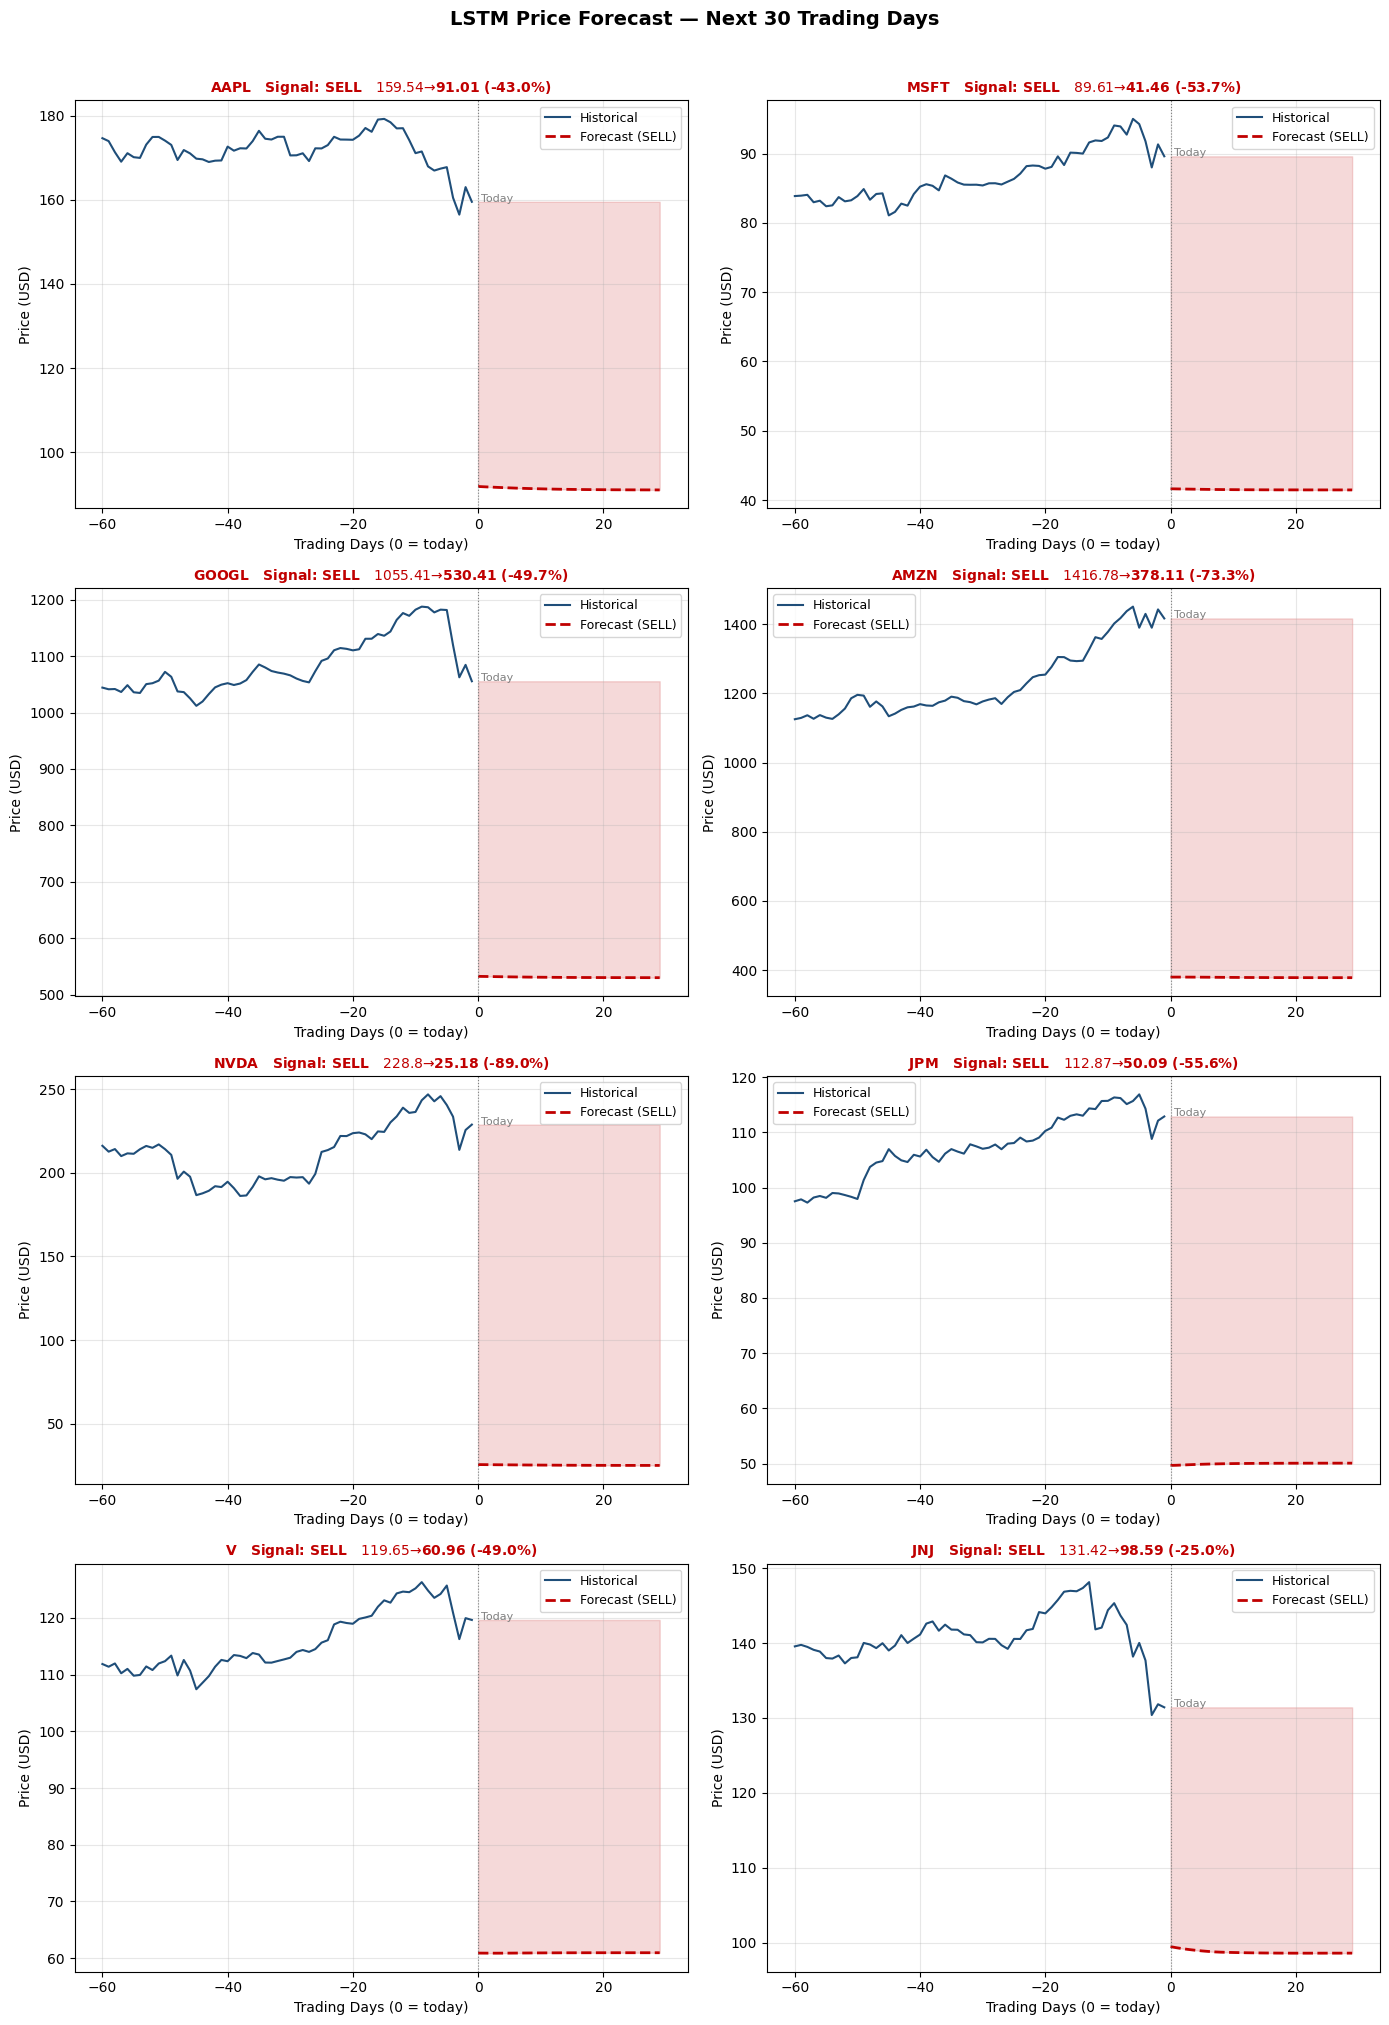

In [ ]:
# Plot future price forecast for all stocks
n    = len(recommendations)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten() if n > 1 else [axes]

signal_colors = {"BUY": "#1D7A3E", "HOLD": "#B8860B", "SELL": "#C00000"}

for ax, (ticker, rec) in zip(axes, recommendations.items()):
    df_f  = stock_feat[ticker]
    hist  = df_f["close"].iloc[-60:].values      # last 60 days of real history
    fut   = rec["future_prices"]
    color = signal_colors[rec["signal"]]

    # Historical prices
    x_hist = np.arange(-len(hist), 0)
    ax.plot(x_hist, hist, color="#1F4E79", linewidth=1.5, label="Historical")

    # Forecast
    x_fut = np.arange(0, len(fut))
    ax.plot(x_fut, fut, color=color, linewidth=2.0,
            linestyle="--", label=f"Forecast ({rec['signal']})")
    ax.fill_between(x_fut, fut, hist[-1], alpha=0.15, color=color)

    # Vertical line at today
    ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.text(0.5, hist[-1], "Today", fontsize=8, color="gray")

    # Annotation box
    gain_str = f"{rec['predicted_gain']:+.1f}%"
    ax.set_title(
        f"{ticker}   Signal: {rec['signal']}   "
        f"${rec['current_price']} → ${rec['target_price']} ({gain_str})",
        fontsize=10, fontweight="bold", color=color
    )
    ax.set_xlabel("Trading Days (0 = today)")
    ax.set_ylabel("Price (USD)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle(f"LSTM Price Forecast — Next {FORECAST_DAYS} Trading Days",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Section 10 — Final Recommendation Dashboard

In [ ]:
# ── Print the full recommendation table ───────────────────────────────────────
print("=" * 90)
print(f"  STOCK RECOMMENDATION DASHBOARD   (Forecast: next {FORECAST_DAYS} trading days)")
print("=" * 90)
print(f"{'Stock':8s}  {'Signal':6s}  {'Current':>9s}  {'Target':>9s}  "
      f"{'Gain%':>8s}  {'Peak':>9s}  {'Peak Day':>8s}  {'Confidence':>12s}")
print("-" * 90)

buy_list  = []
hold_list = []
sell_list = []

for ticker, rec in sorted(recommendations.items(),
                           key=lambda x: x[1]["predicted_gain"], reverse=True):
    print(
        f"{ticker:8s}  "
        f"{rec['signal']:6s}  "
        f"${rec['current_price']:>8.2f}  "
        f"${rec['target_price']:>8.2f}  "
        f"{rec['predicted_gain']:>+7.1f}%  "
        f"${rec['peak_price']:>8.2f}  "
        f"{rec['peak_day']:>7d}d  "
        f"{rec['model_confidence']:>12s}"
    )
    if rec["signal"] == "BUY":  buy_list.append(ticker)
    elif rec["signal"] == "HOLD": hold_list.append(ticker)
    else: sell_list.append(ticker)

print("-" * 90)
print(f"  BUY  ({len(buy_list)})  : {', '.join(buy_list)  if buy_list  else 'None'}")
print(f"  HOLD ({len(hold_list)}) : {', '.join(hold_list) if hold_list else 'None'}")
print(f"  SELL ({len(sell_list)}) : {', '.join(sell_list) if sell_list else 'None'}")
print("=" * 90)
print()
print("DISCLAIMER: These predictions are for research and educational purposes only.")
print("Do NOT use as actual financial advice. Past performance does not guarantee future results.")

  STOCK RECOMMENDATION DASHBOARD   (Forecast: next 30 trading days)
Stock     Signal    Current     Target     Gain%       Peak  Peak Day    Confidence
------------------------------------------------------------------------------------------
JNJ       SELL    $  131.42  $   98.59    -25.0%  $   99.45        1d        Medium
AAPL      SELL    $  159.54  $   91.01    -43.0%  $   91.83        1d        Medium
V         SELL    $  119.65  $   60.96    -49.0%  $   60.96       30d        Medium
GOOGL     SELL    $ 1055.41  $  530.41    -49.7%  $  532.73        1d           Low
MSFT      SELL    $   89.61  $   41.46    -53.7%  $   41.62        1d        Medium
JPM       SELL    $  112.87  $   50.09    -55.6%  $   50.09       30d           Low
AMZN      SELL    $ 1416.78  $  378.11    -73.3%  $  379.82        2d           Low
NVDA      SELL    $  228.80  $   25.18    -89.0%  $   25.68        1d           Low
-------------------------------------------------------------------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

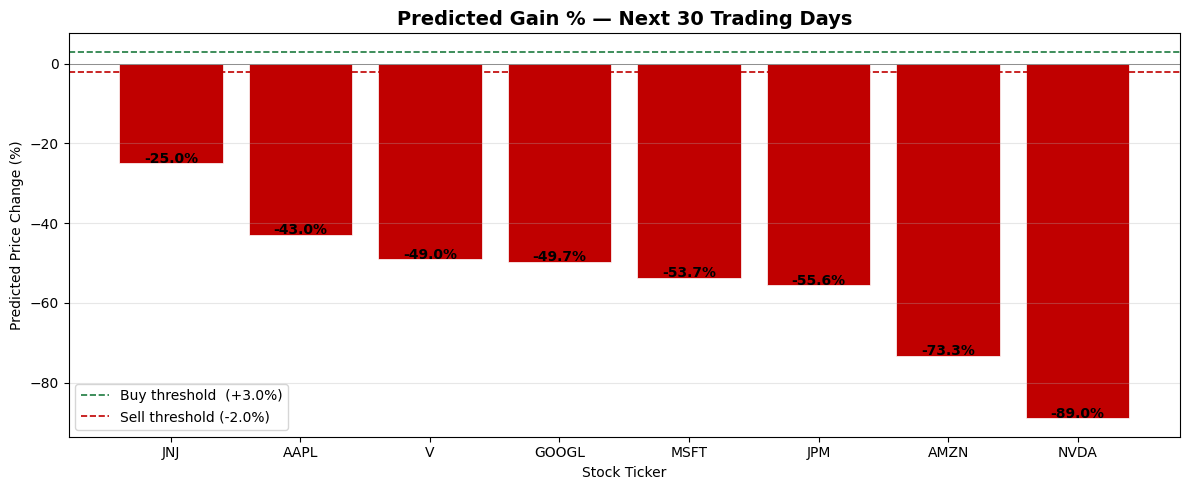

In [ ]:
# Visual dashboard — ranked bar chart
tickers_sorted = sorted(recommendations.keys(),
                         key=lambda t: recommendations[t]["predicted_gain"], reverse=True)
gains  = [recommendations[t]["predicted_gain"] for t in tickers_sorted]
colors = [signal_colors[recommendations[t]["signal"]] for t in tickers_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(tickers_sorted, gains, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(BUY_THRESHOLD,  color="#1D7A3E", linestyle="--", linewidth=1.2,
           label=f"Buy threshold  (+{BUY_THRESHOLD}%)")
ax.axhline(SELL_THRESHOLD, color="#C00000", linestyle="--", linewidth=1.2,
           label=f"Sell threshold ({SELL_THRESHOLD}%)")
ax.axhline(0, color="gray", linewidth=0.6)

for bar, gain in zip(bars, gains):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (0.3 if gain >= 0 else -0.6),
        f"{gain:+.1f}%",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title(f"Predicted Gain % — Next {FORECAST_DAYS} Trading Days",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Predicted Price Change (%)")
ax.set_xlabel("Stock Ticker")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Accuracy metrics comparison across all stocks
metrics_df = pd.DataFrame([
    {
        "Ticker"           : t,
        "RMSE (USD)"       : eval_results[t]["RMSE (USD)"],
        "MAPE (%)"         : eval_results[t]["MAPE (%)"],
        "R²"               : eval_results[t]["R²"],
        "Dir Accuracy (%)" : eval_results[t]["Dir Accuracy (%)"],
        "Signal"           : recommendations[t]["signal"],
        "Predicted Gain (%)": recommendations[t]["predicted_gain"]
    }
    for t in recommendations
]).set_index("Ticker").sort_values("Predicted Gain (%)", ascending=False)

print("\nFull accuracy and recommendation table:")
print(metrics_df.to_string())


Full accuracy and recommendation table:
        RMSE (USD)  MAPE (%)       R²  Dir Accuracy (%) Signal  Predicted Gain (%)
Ticker                                                                            
JNJ        36.6813     26.65 -54.0568              58.0   SELL              -24.98
AAPL       68.6838     42.04 -45.1778              54.1   SELL              -42.95
V          46.3765     42.52 -27.5121              53.0   SELL              -49.05
GOOGL     482.7966     47.22 -50.6598              47.0   SELL              -49.74
MSFT       37.2677     46.37 -25.7183              56.9   SELL              -53.74
JPM        48.1486     48.27 -29.5241              44.8   SELL              -55.62
AMZN      710.0832     64.57 -28.4747              49.2   SELL              -73.31
NVDA      160.7266     86.16 -33.0977              51.9   SELL              -88.99


## Section 11 — Save All Outputs

In [ ]:
# Save recommendation table
metrics_df.to_csv("stock_recommendations.csv")
print("Saved: stock_recommendations.csv")

# Save future price forecasts
forecast_df = pd.DataFrame({
    ticker: rec["future_prices"]
    for ticker, rec in recommendations.items()
})
forecast_df.index.name = "Day"
forecast_df.to_csv("future_price_forecasts.csv")
print("Saved: future_price_forecasts.csv")

# Save trained models
for ticker, model in trained_models.items():
    model.save(f"{ticker}_lstm_model.keras")
    print(f"Saved: {ticker}_lstm_model.keras")

print("\nAll outputs saved")
print("\nFiles you can download from Colab:")
print("  stock_recommendations.csv    — buy/hold/sell table with predicted gains")
print("  future_price_forecasts.csv   — day-by-day price forecast for each stock")
print("  {TICKER}_lstm_model.keras    — trained model weights for each stock")

Saved: stock_recommendations.csv
Saved: future_price_forecasts.csv
Saved: AAPL_lstm_model.keras
Saved: MSFT_lstm_model.keras
Saved: GOOGL_lstm_model.keras
Saved: AMZN_lstm_model.keras
Saved: NVDA_lstm_model.keras
Saved: JPM_lstm_model.keras
Saved: V_lstm_model.keras
Saved: JNJ_lstm_model.keras

All outputs saved

Files you can download from Colab:
  stock_recommendations.csv    — buy/hold/sell table with predicted gains
  future_price_forecasts.csv   — day-by-day price forecast for each stock
  {TICKER}_lstm_model.keras    — trained model weights for each stock
